In [174]:
import pandas as pd

# Load the e-commerce dataset
df = pd.read_csv("../data/ecommerce_sales.csv")

# Display the first 5 rows
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount,Revenue,Region,Payment_Method
0,ORD10933,2025-01-01,CUST1033,Office Chair,Furniture,4,180,0.00,720.0,South,Debit Card
1,ORD10850,2025-01-01,CUST1250,Office Chair,Furniture,4,180,0.00,720.0,East,Cash on Delivery
2,ORD10873,2025-01-01,CUST1273,Keyboard,Accessories,1,45,0.00,45.0,South,Debit Card
3,ORD10027,2025-01-01,CUST1027,Tablet,Electronics,4,310,0.05,1178.0,East,Credit Card
4,ORD10811,2025-01-02,CUST1211,Headphones,Electronics,4,75,0.05,285.0,East,UPI


In [175]:
# Check the size of the dataset
print("Rows and columns:", df.shape)

# Check column names and data types
df.info()

Rows and columns: (1000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1000 non-null   str    
 1   Order_Date      1000 non-null   str    
 2   Customer_ID     1000 non-null   str    
 3   Product         1000 non-null   str    
 4   Category        1000 non-null   str    
 5   Quantity        1000 non-null   int64  
 6   Unit_Price      1000 non-null   int64  
 7   Discount        1000 non-null   float64
 8   Revenue         1000 non-null   float64
 9   Region          1000 non-null   str    
 10  Payment_Method  1000 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 86.1 KB


In [176]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [177]:
# Convert Order_Date to a proper date format
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Check the result
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1000 non-null   str           
 1   Order_Date      1000 non-null   datetime64[us]
 2   Customer_ID     1000 non-null   str           
 3   Product         1000 non-null   str           
 4   Category        1000 non-null   str           
 5   Quantity        1000 non-null   int64         
 6   Unit_Price      1000 non-null   int64         
 7   Discount        1000 non-null   float64       
 8   Revenue         1000 non-null   float64       
 9   Region          1000 non-null   str           
 10  Payment_Method  1000 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(6)
memory usage: 86.1 KB


In [178]:
# Basic sales statistics
print("Total Revenue:", df["Revenue"].sum())
print("Average Order Revenue:", df["Revenue"].mean())
print("Total Quantity Sold:", df["Quantity"].sum())

Total Revenue: 664528.75
Average Order Revenue: 664.52875
Total Quantity Sold: 3054


In [179]:
# Revenue by category
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print(category_revenue)

Category
Electronics    523464.50
Furniture      102000.00
Accessories     21926.25
Bags            17138.00
Name: Revenue, dtype: float64


In [180]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print(category_revenue)

Category
Electronics    523464.50
Furniture      102000.00
Accessories     21926.25
Bags            17138.00
Name: Revenue, dtype: float64


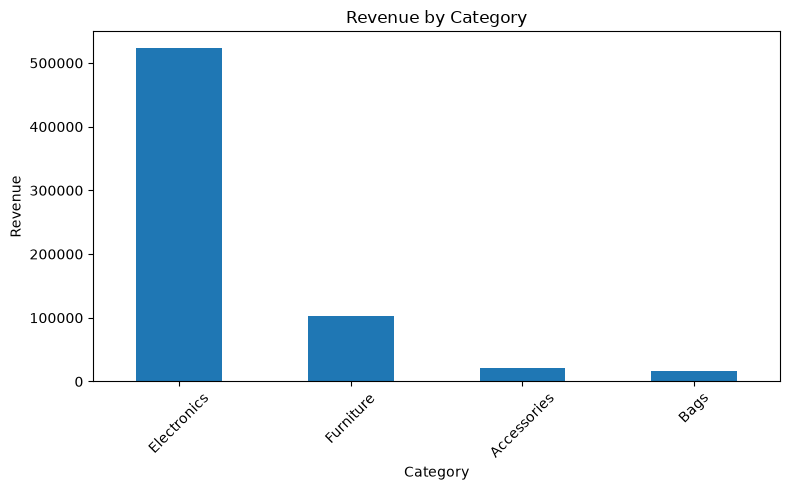

In [181]:
import matplotlib.pyplot as plt

category_revenue.plot(kind="bar", figsize=(8, 5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [182]:
# Revenue by region
region_revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

print(region_revenue)

Region
West     177505.75
East     172219.50
North    158497.75
South    156305.75
Name: Revenue, dtype: float64


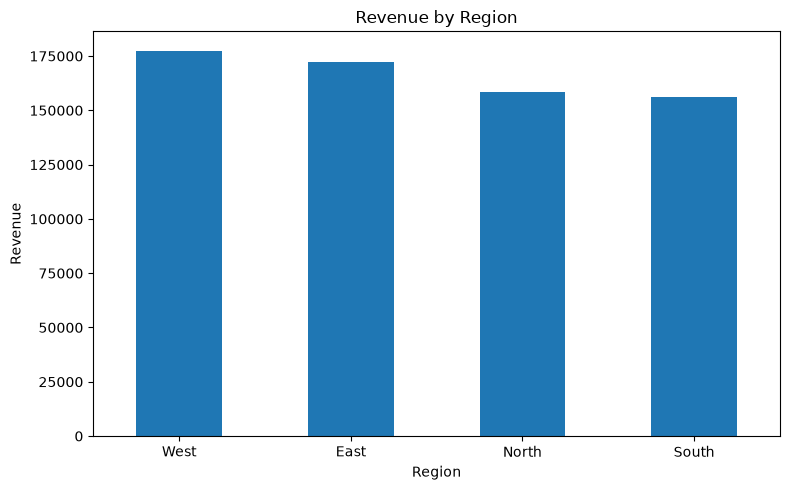

In [183]:
# Visualize revenue by region
region_revenue.plot(kind="bar", figsize=(8, 5))

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [184]:
# Total quantity sold by product
product_sales = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

print(product_sales)

Product
Laptop          362
Headphones      341
Backpack        324
Mouse           323
Tablet          317
Keyboard        296
Monitor         281
Office Chair    272
Smartphone      272
Desk            266
Name: Quantity, dtype: int64


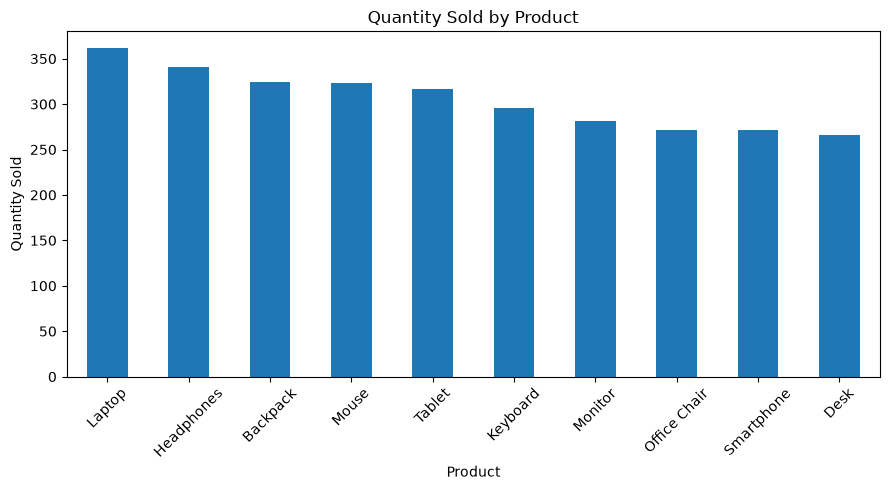

In [185]:
# Visualize top-selling products
product_sales.plot(kind="bar", figsize=(9, 5))

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [186]:
# Create a month column
df["Month"] = df["Order_Date"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()

print(monthly_revenue)

Month
2025-01    61945.25
2025-02    48561.75
2025-03    55143.00
2025-04    53685.00
2025-05    53177.25
2025-06    57138.75
2025-07    52219.25
2025-08    58536.25
2025-09    45260.50
2025-10    57558.50
2025-11    66019.50
2025-12    55283.75
Freq: M, Name: Revenue, dtype: float64


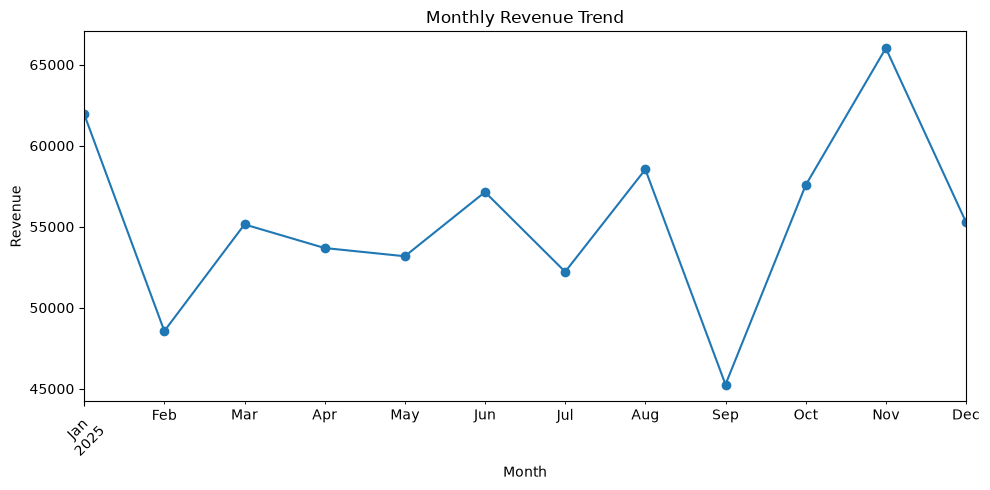

In [187]:
# Monthly revenue trend
monthly_revenue.plot(kind="line", figsize=(10, 5), marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [188]:
# Count orders by payment method
payment_counts = df["Payment_Method"].value_counts()

print(payment_counts)

Payment_Method
UPI                 308
Credit Card         251
Debit Card          188
Cash on Delivery    155
Net Banking          98
Name: count, dtype: int64


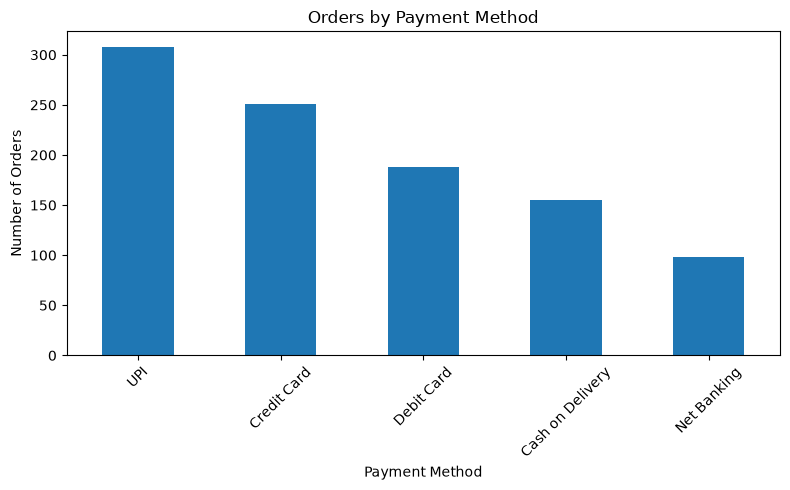

In [189]:
# Visualize payment methods
payment_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [190]:
# Average discount by category
discount_by_category = df.groupby("Category")["Discount"].mean().sort_values(ascending=False)

print(discount_by_category)

Category
Furniture      0.048947
Accessories    0.046269
Electronics    0.044106
Bags           0.038500
Name: Discount, dtype: float64


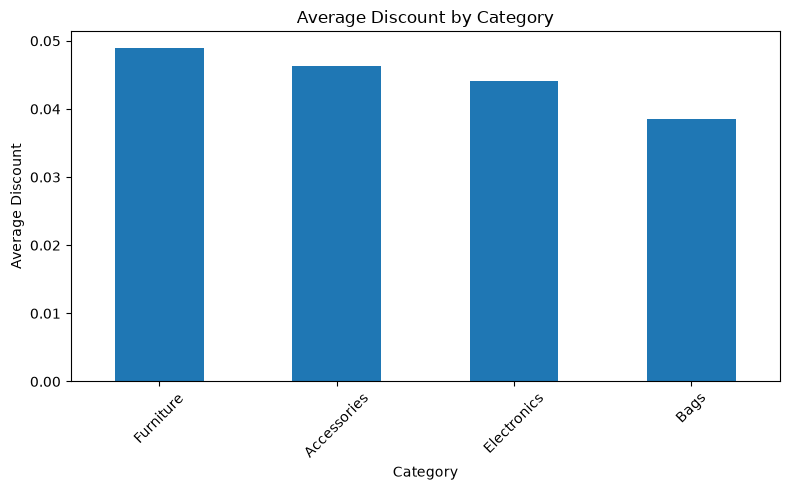

In [191]:
# Visualize average discount by category
discount_by_category.plot(kind="bar", figsize=(8, 5))

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [192]:
# Key Business Insights

top_product = df.groupby("Product")["Quantity"].sum().idxmax()
top_product_quantity = df.groupby("Product")["Quantity"].sum().max()

top_category = df.groupby("Category")["Revenue"].sum().idxmax()
top_category_revenue = df.groupby("Category")["Revenue"].sum().max()

top_region = df.groupby("Region")["Revenue"].sum().idxmax()
top_region_revenue = df.groupby("Region")["Revenue"].sum().max()

best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

most_used_payment = df["Payment_Method"].value_counts().idxmax()

average_discount = df["Discount"].mean()

print("===== BUSINESS INSIGHTS =====")
print("Top-selling product:", top_product)
print("Quantity sold:", top_product_quantity)
print()
print("Highest revenue category:", top_category)
print("Category revenue:", round(top_category_revenue, 2))
print()
print("Highest revenue region:", top_region)
print("Region revenue:", round(top_region_revenue, 2))
print()
print("Best revenue month:", best_month)
print("Monthly revenue:", round(best_month_revenue, 2))
print()
print("Most used payment method:", most_used_payment)
print()
print("Average discount:", round(average_discount, 2))

===== BUSINESS INSIGHTS =====
Top-selling product: Laptop
Quantity sold: 362

Highest revenue category: Electronics
Category revenue: 523464.5

Highest revenue region: West
Region revenue: 177505.75

Best revenue month: 2025-11
Monthly revenue: 66019.5

Most used payment method: UPI

Average discount: 0.04
